<a href="https://colab.research.google.com/github/Sandu70one/ml-labs/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast

# specify GPU
device = torch.device("cuda")

In [ ]:
df = pd.read_csv("spamemaildata.csv")
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5572, 2)

Email Class Distribution:
 - 0 emails: 86.59% of the dataset
 - 1 emails: 13.41% of the dataset

--------------------------------------------------
Missing Values Per Column:
 - label column has 0 missing values
 - text column has 0 missing values

--------------------------------------------------
Duplicate Rows: There are 403 duplicate rows in the dataset

--------------------------------------------------
Email Length Statistics:
 - Shortest email: 1 words
 - Longest email: 171 words
 - Average email length: 15.49 words

Average length by label:
label
0    14.200622
1    23.851406
Name: length, dtype: float64

--------------------------------------------------


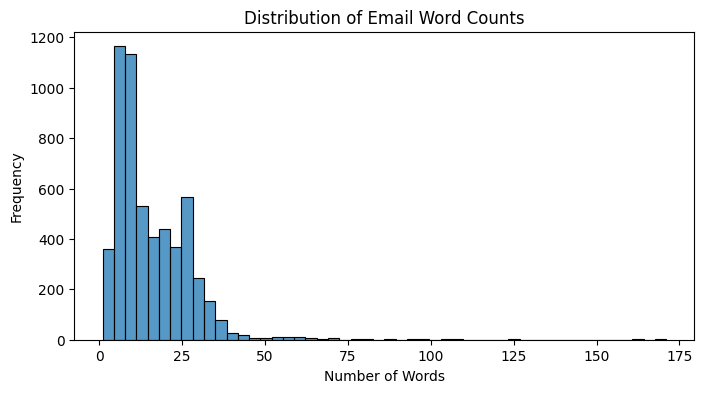

Stylistic Analysis Statistics:
       uppercase_count  exclamation_count  currency_count  stopword_ratio
count      5572.000000        5572.000000     5572.000000     5572.000000
mean          5.564429           0.247846        0.062994        0.068800
std          11.130981           0.681146        0.296237        0.078960
min           0.000000           0.000000        0.000000        0.000000
25%           1.000000           0.000000        0.000000        0.000000
50%           2.000000           0.000000        0.000000        0.047619
75%           4.000000           0.000000        0.000000        0.117647
max         128.000000          11.000000        3.000000        0.500000

--------------------------------------------------
Top 20 Spam Words: [('to', 682), ('a', 373), ('call', 342), ('your', 263), ('you', 252), ('the', 204), ('for', 201), ('or', 188), ('free', 180), ('2', 169), ('is', 152), ('ur', 144), ('on', 141), ('txt', 136), ('have', 135), ('from', 127), ('and', 122

In [ ]:
# Full Exploratory Data Analysis (EDA)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# --- 1️⃣ Class Distribution (Spam vs Ham) ---
label_ratio = df['label'].value_counts(normalize=True)
print("Email Class Distribution:")
for label, ratio in label_ratio.items():
    print(f" - {label} emails: {ratio:.2%} of the dataset")
print("\n" + "-"*50)

# --- 2️⃣ Missing Data ---
missing = df.isnull().sum()
print("Missing Values Per Column:")
for column, count in missing.items():
    print(f" - {column} column has {count} missing values")
print("\n" + "-"*50)

# --- 3️⃣ Duplicate Rows ---
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: There are {duplicates} duplicate rows in the dataset")
print("\n" + "-"*50)

# --- 4️⃣ Email Length Analysis ---
df['length'] = df['text'].apply(lambda x: len(x.split()))
df['char_count'] = df['text'].apply(len)

print("Email Length Statistics:")
print(f" - Shortest email: {df['length'].min()} words")
print(f" - Longest email: {df['length'].max()} words")
print(f" - Average email length: {df['length'].mean():.2f} words")
print("\nAverage length by label:")
print(df.groupby('label')['length'].mean())
print("\n" + "-"*50)

# Histogram of email lengths
plt.figure(figsize=(8,4))
sns.histplot(df['length'], bins=50)
plt.title("Distribution of Email Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# --- 5️⃣ Stylistic Analysis ---
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))
df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))
df['currency_count'] = df['text'].apply(lambda x: sum(x.count(s) for s in ['$','£','€']))
stopwords = set(["the","is","at","which","on","and","a","an","in"])
df['stopword_ratio'] = df['text'].apply(lambda x: sum(1 for w in x.lower().split() if w in stopwords)/len(x.split()))

print("Stylistic Analysis Statistics:")
print(df[['uppercase_count','exclamation_count','currency_count','stopword_ratio']].describe())
print("\n" + "-"*50)

# --- 6️⃣ Vocabulary & N-Gram Analysis ---
spam_text = df[df['label']==1]['text']
ham_text = df[df['label']==0]['text']

# Top 20 words
spam_words = ' '.join(spam_text).lower().split()
ham_words = ' '.join(ham_text).lower().split()
print("Top 20 Spam Words:", Counter(spam_words).most_common(20))
print("Top 20 Ham Words:", Counter(ham_words).most_common(20))

# Top 20 bigrams in Spam
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X_spam = vectorizer.fit_transform(spam_text)
bigram_counts = X_spam.sum(axis=0)
bigrams = [(word, bigram_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigrams.sort(key=lambda x: x[1], reverse=True)
print("Top 20 Spam Bigrams:", bigrams[:20])

In [ ]:
# remove duplecates
df = df.drop_duplicates(subset='text').reset_index(drop=True)

In [ ]:
df.shape

(5169, 8)

In [ ]:

df = df.drop(columns=['length', 'char_count', 'uppercase_count',
                      'exclamation_count', 'currency_count', 'stopword_ratio'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
#because of the class imbalance import another dataset that have larage amount of data, and concat to the previous one
# Load the new spam data

# df2 = pd.read_csv('/content/addirional_spamemaildata.csv')
# print(df.columns)
# print(df2.columns)

Index(['label', 'text'], dtype='object')
Index(['label', 'text'], dtype='object')


In [ ]:
# # Stack df2 under df1
# df = pd.concat([df, df2], axis=0)

# # Reset the index
# # Without this, duplicate index numbers can be present
# df = df.reset_index(drop=True)

In [ ]:
# #new dataset
df.shape

(5169, 2)

In [ ]:
#check the distribution
label_ratio = df['label'].value_counts(normalize=True)
print("Email Class Distribution:")
for label, ratio in label_ratio.items():
    print(f" - {label} emails: {ratio:.2%} of the dataset")
print("\n" + "-"*50)

Email Class Distribution:
 - 0 emails: 87.37% of the dataset
 - 1 emails: 12.63% of the dataset

--------------------------------------------------


In [ ]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['text'], df['label'],
                                                                    random_state=2018,
                                                                    test_size=0.3,
                                                                    stratify=df['label'])
# stratify Look'label' column. Whatever the percentage of 0s and 1s is there, make sure new split looks exactly like that.
# we will use temp_text and temp_labels to create validation and test set
val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels,
                                                                random_state=2018,
                                                                test_size=0.5,
                                                                stratify=temp_labels)

In [ ]:
# import BERT-base pretrained model
bert = AutoModel.from_pretrained('bert-base-uncased')

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# sample data
text = ["test my text to check the tokenizatio"]

# encode text
sent_id = tokenizer(text, padding=True, truncation=True, return_tensors="pt")

In [ ]:
print(sent_id)
#

{'input_ids': tensor([[  101,  3231,  2026,  3793,  2000,  4638,  1996, 19204, 21335,  3775,
          2080,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


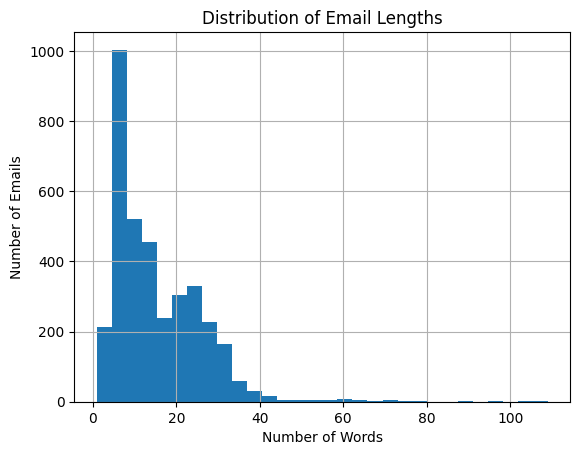

In [ ]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in train_text]

# 1. Create the histogram
pd.Series(seq_len).hist(bins=30)

# 2. Add the titles and labels
plt.title("Distribution of Email Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Emails")

# 3. Clean up the display
plt.show()

In [ ]:
# Check what length covers 95% of your data
percentile_95 = np.percentile(seq_len, 95)
print(f"95% of emails are {percentile_95} words or shorter.")

95% of emails are 33.0 words or shorter.


In [ ]:
#Tokenize the Train test and validation dataset

#Max Sequence Length is the fixed number of "slots" you allocate for each email.
#Every email you feed into the model will be forced to be exactly this length.
max_seq_len = 35

# tokenize and encode sequences in the training set
tokens_train = tokenizer(
    train_text.tolist(),
    max_length = max_seq_len,
    padding=True ,
    truncation=True,
    return_token_type_ids=False
)

# tokenize and encode sequences in the validation set
tokens_val = tokenizer(
    val_text.tolist(),
    max_length = max_seq_len,
    padding=True ,
    truncation=True,
    return_token_type_ids=False,

)

# tokenize and encode sequences in the test set
tokens_test = tokenizer(
    test_text.tolist(),
    max_length = max_seq_len,
    padding=True ,
    truncation=True,
    return_token_type_ids=False
)

In [ ]:
# Deep learning models like BERT are massive and require the parallel
# processing power of a GPU
# Tensors are the only data structure that PyTorch can "ship" over to the GPU
# (like Lists, arrays)

# for train set
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

# for validation set
val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

# for test set
test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

**DataLoaders & Batching**

**Memory Management:** You cannot feed all 5,000+ emails into BERT at once. Doing so would exceed the GPU's VRAM.


**The Batch Solution:** Data is broken into small, manageable groups called Batches (standard sizes are 16 or 32, as mentioned in the BERT model documentation). BERT processes one batch at a time.

**Mini-Batch Gradient Descent:** This is the core training logic. The model calculates its error and updates its parameters after each batch, making the learning process faster and more stable.

**RandomSampler (Training):** Crucial for "shuffling" the deck. It ensures the model doesn't learn the order of the data, but the content of the data (prevents overfitting).

**SequentialSampler (Validation/Test):** Shuffling during testing is unnecessary and bad practice. You need a stable, repeatable yardstick to measure your model's real progress.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
#Batch Size × Max Seq Len = Total GPU Memory Used.
batch_size = 32

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

print(f"train_seq type: {type(train_seq)}, shape: {train_seq.shape}")
print(f"train_mask type: {type(train_mask)}, shape: {train_mask.shape}")
print(f"train_y type: {type(train_y)}, shape: {train_y.shape}")

train_seq type: <class 'torch.Tensor'>, shape: torch.Size([3618, 35])
train_mask type: <class 'torch.Tensor'>, shape: torch.Size([3618, 35])
train_y type: <class 'torch.Tensor'>, shape: torch.Size([3618])
